In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import os
from scipy.sparse import coo_matrix

In [2]:
from kaggle.api.kaggle_api_extended import KaggleApi
import zipfile

# Authenticate
api = KaggleApi()
api.authenticate()

# Download dataset
dataset = "snap/amazon-fine-food-reviews"
api.dataset_download_files(dataset, path="data", unzip=True)

# Load file
file_path = "data/Reviews.csv"

data = pd.read_csv(file_path)

# Show data
print(data.head())
print(data.columns)

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Go

In [3]:
data

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [5]:
data['ProfileName'] = data['ProfileName'].fillna("Unknown")
data['Summary'] = data['Summary'].fillna("Unknown")

In [6]:
data.isnull().sum()

Id                        0
ProdID                    0
UserId                    0
ProfileName               0
HelpfulCount              0
HelpfulnessDenominator    0
Rating                    0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [7]:
data.duplicated().sum()

0

In [8]:
#  Correct column mapping based on actual Amazon Reviews dataset columns
# Actual columns: Id, ProductId, UserId, ProfileName, HelpfulnessNumerator,
#                 HelpfulnessDenominator, Score, Time, Summary, Text

column_name_mapping = {
    'ProductId': 'ProdID',
    'Score': 'Rating',                        # FIX: 'Score' is the actual rating column
    'HelpfulnessNumerator': 'HelpfulCount',   # FIX: renamed to avoid confusion
}

# Rename the columns using the mapping
data.rename(columns=column_name_mapping, inplace=True)
data['ProdID'] = pd.factorize(data['ProdID'])[0]

print("Columns after renaming:", data.columns.tolist())

Columns after renaming: ['Id', 'ProdID', 'UserId', 'ProfileName', 'HelpfulCount', 'HelpfulnessDenominator', 'Rating', 'Time', 'Summary', 'Text']


In [9]:
# data = data.head(5000).copy()

In [10]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def create_tags(text):
    text = str(text).lower()
    words = re.findall(r'\b[a-z]+\b', text)  # only words
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return ' '.join(words[:30])  # top 30 words as tags

In [11]:
data['Tags'] = (
    data['Summary'].fillna('') + ' ' +
    data['Text'].fillna('')
).apply(create_tags)

In [12]:
data['ProductName'] = (
    data['Summary'].astype(str) + " - " +
    data['Tags'].astype(str)
)

In [13]:
########  Content Based Recommendation System  ##########

In [14]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def content_based_recommendations(data, item_name, top_n=10):
    """
    Returns top N product recommendations based on content similarity.
    Uses TF-IDF vectorization on product tags and cosine similarity.
    """
    # 1. Clean input and find matching rows using partial matching
    clean_input = item_name.split('-')[0].strip()

    matches = data[data['ProductName'].str.contains(clean_input, case=False, na=False)]

    if matches.empty:
        print(f" Item '{item_name}' not found in the dataset. Try a different keyword.")
        return pd.DataFrame()

    # Get the index of the first matched item
    item_index = matches.index[0]
    print(f" Matched: '{data.loc[item_index, 'Summary']}'")

    # 2. Vectorize the Tags column using TF-IDF
    tfidf_vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix_content = tfidf_vectorizer.fit_transform(data['Tags'].fillna(''))

    # 3. Compute cosine similarity for the matched item only (efficient)
    item_vector = tfidf_matrix_content[item_index]
    cosine_similarities = cosine_similarity(item_vector, tfidf_matrix_content).flatten()

    # 4. Sort by similarity, exclude the item itself, take top N
    similar_indices = cosine_similarities.argsort()[::-1]
    similar_indices = [idx for idx in similar_indices if idx != item_index][:top_n]

    # 5. Return results with clean columns
    results = data.iloc[similar_indices][['ProductName', 'Rating', 'Text']].copy()
    results['Similarity'] = [round(cosine_similarities[i], 4) for i in similar_indices]
    return results

In [15]:
# FIX: Take proper user input instead of hardcoded value
item_name = input(" Enter a product name or keyword to get recommendations: ").strip()

if not item_name:
    print(" Please enter a valid product name or keyword.")
else:
    content_based_rec = content_based_recommendations(data, item_name, top_n=8)

    if not content_based_rec.empty:
        print(f"\n\ Top recommendations for: '{item_name}'\n")
        display(content_based_rec[['ProductName', 'Rating', 'Similarity']])
    else:
        print("No recommendations found. Try a broader keyword.")

 Enter a product name or keyword to get recommendations:  Instant Oatmeal


 Matched: 'Best of the Instant Oatmeals'

\ Top recommendations for: 'Instant Oatmeal'



,ProductName,Rating,Similarity
28133,Typical instant oatmeal - typical instant oatm...,3,0.5911
64951,Typical instant oatmeal - typical instant oatm...,3,0.5911
348588,Best instant oatmeal out there - best instant ...,5,0.5819
151843,McCann's Irish Oatmeal in instant packets - mc...,5,0.5773
34,Great Irish oatmeal for those in a hurry! - gr...,5,0.5695
346926,"Glutenfreeda's Instant Oatmeal, Natural - glut...",5,0.5631
444991,Instant Oatmeal - instant oatmeal simply best ...,5,0.5588
151884,The World's Best Instant Oatmeal - world s bes...,5,0.5584


C:\Users\VENGEANCE\AppData\Local\Temp\ipykernel_11040\2261311045.py:29: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\VENGEANCE\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


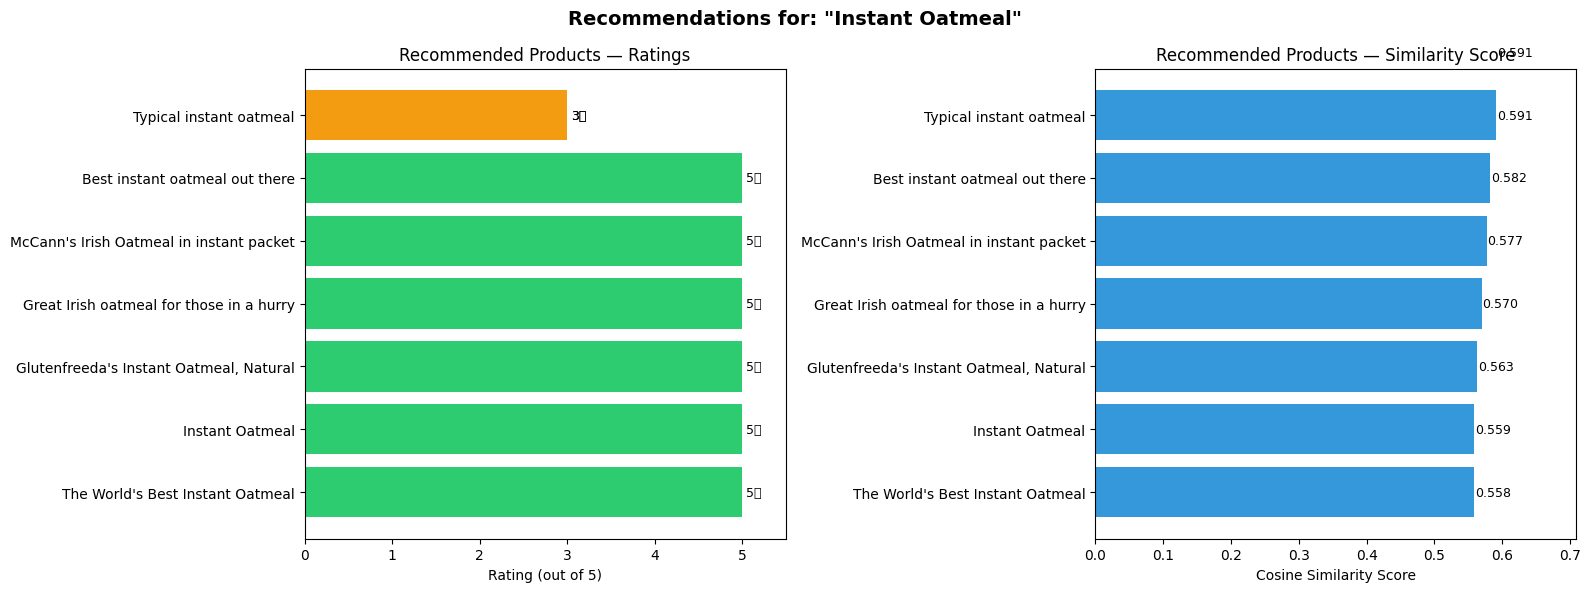

In [16]:
#  Visualization of recommended items
if not content_based_rec.empty:
    # Shorten product names for display
    display_names = content_based_rec['ProductName'].str.split(' - ').str[0].str[:40]
    ratings = content_based_rec['Rating']
    similarities = content_based_rec['Similarity']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Recommendations for: "{item_name}"', fontsize=14, fontweight='bold')

    # --- Chart 1: Ratings bar chart ---
    colors = ['#2ecc71' if r >= 4 else '#f39c12' if r == 3 else '#e74c3c' for r in ratings]
    bars = axes[0].barh(display_names[::-1], ratings[::-1], color=colors[::-1])
    axes[0].set_xlabel('Rating (out of 5)')
    axes[0].set_title('Recommended Products — Ratings')
    axes[0].set_xlim(0, 5.5)
    for bar, val in zip(bars, ratings[::-1]):
        axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                     f'{val}⭐', va='center', fontsize=9)

    # --- Chart 2: Similarity score bar chart ---
    axes[1].barh(display_names[::-1], similarities[::-1], color='#3498db')
    axes[1].set_xlabel('Cosine Similarity Score')
    axes[1].set_title('Recommended Products — Similarity Score')
    axes[1].set_xlim(0, max(similarities) * 1.2)
    for i, (name, sim) in enumerate(zip(display_names[::-1], similarities[::-1])):
        axes[1].text(sim + 0.001, i, f'{sim:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")